In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import cartopy.io.shapereader as shpreader
import matplotlib.colors as colors

In [3]:
import numpy as np
import pandas as pd

dayall = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20',
          '21','22','23','24','25','26','27','28','29','30','31']
years = ['2015','2016','2017','2018','2019']  # 选择 5 年的数据
mons = ['01','02','03','04','05','06','07','08','09','10','11','12']

# 创建 12 个月份的累积矩阵
ZZ_sum_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的累计值
num_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的有效点数

for imon_idx, imon in enumerate(mons):
    for iyear in years:
        # 判断月份天数
        if imon in ['01', '03', '05', '07', '08', '10', '12']:
            day = dayall[:]
        elif imon in ['04', '06', '09', '11']:
            day = dayall[:-1]
        elif imon == '02':
            day = dayall[:-3]  # 假设不考虑闰年
        
        # 遍历每一天的数据
        for iday in day:
            filename = f'D:/workdata/43_met_station_statistic/xco2/obs2015to2020/obs.{iyear}{imon}{iday}T+00.csv'
            try:
                df1 = pd.read_csv(filename)
            except FileNotFoundError:
                print(f"File not found: {filename}")
                continue  # 跳过不存在的文件
            
            # 读取数据
            lat1 = df1['lat']
            lon1 = df1['lon']
            xco21 = df1['xco2']

            # 创建网格化
            X, Y = np.mgrid[-179.5:179.5:complex(0, 360), -89.5:89.5:complex(0, 180)]
            ZZ = np.zeros((360, 180))

            # 将数据离散化到网格上
            lon_g = np.floor(lon1[:]-0.000001)+0.5
            lat_g = np.floor(lat1[:]-0.000001)+0.5
            index_lon = np.int_(lon_g.values[:] + 179.5)
            index_lat = np.int_(lat_g.values[:] + 89.5)
            
            # 对应位置赋值
            ZZ[index_lon, index_lat] = xco21
            
            # 累加当天的数据到对应月份
            ZZ_sum_all_months[imon_idx] += ZZ
            ZZ[np.where(ZZ > 0)] = 1
            num_all_months[imon_idx] += ZZ

# 计算五年平均
num_all_months[num_all_months == 0] = np.nan  # 避免除以 0
ZZ_mean_all_months = ZZ_sum_all_months / num_all_months  # 得到每个月的五年平均



In [4]:
ZZ_mean_all_months_oco2 = ZZ_mean_all_months

In [5]:

# 假设 ZZ_mean_all_months 形状为 (num_months, 180, 360)
# 提取第2、3、4个月的数据（即索引2、3、4）
spring_months = ZZ_mean_all_months[[2, 3, 4], :, :] 
summer_months = ZZ_mean_all_months[[5, 6, 7], :, :] 
autumn_months = ZZ_mean_all_months[[8, 9, 10], :, :] 
winter_months = ZZ_mean_all_months[[11, 0, 1], :, :]  # 形状变为 (3, 180, 360)

# 沿第0轴（时间轴）计算平均值，忽略 NaN
ZZ_mean_all_spring = np.nanmean(spring_months, axis=0) 
ZZ_mean_all_summer = np.nanmean(summer_months, axis=0) 
ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0) 
ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:9: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_spring = np.nanmean(spring_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:10: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_summer = np.nanmean(summer_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:11: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:12: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)


In [6]:
# 春 3 4 5 夏 6 7 8 秋 9 10 11 冬 12 1 2
ZZ_mean_all_year_oco2 = np.nanmean(ZZ_mean_all_months,axis=0)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\768231153.py:2: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_year_oco2 = np.nanmean(ZZ_mean_all_months,axis=0)


In [7]:
import numpy as np
import pandas as pd

dayall = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20',
          '21','22','23','24','25','26','27','28','29','30','31']
years = ['2015','2016','2017','2018','2019']  # 选择 5 年的数据
mons = ['01','02','03','04','05','06','07','08','09','10','11','12']

# 创建 12 个月份的累积矩阵
ZZ_sum_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的累计值
num_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的有效点数

for imon_idx, imon in enumerate(mons):
    for iyear in years:
        # 判断月份天数
        if imon in ['01', '03', '05', '07', '08', '10', '12']:
            day = dayall[:]
        elif imon in ['04', '06', '09', '11']:
            day = dayall[:-1]
        elif imon == '02':
            day = dayall[:-3]  # 假设不考虑闰年
        
        # 遍历每一天的数据
        for iday in day:
            filename = f'D:/workdata/43_met_station_statistic/xco2/naqpms.gr.country.71/sim.{iyear}{imon}{iday}T+00.zhouRunAll.csv'
            try:
                df1 = pd.read_csv(filename)
            except FileNotFoundError:
                print(f"File not found: {filename}")
                continue  # 跳过不存在的文件
            
            # 读取数据
            lat1 = df1['lat']
            lon1 = df1['lon']
            xco21 = df1['xco2']

            # 创建网格化
            X, Y = np.mgrid[-179.5:179.5:complex(0, 360), -89.5:89.5:complex(0, 180)]
            ZZ = np.zeros((360, 180))

            # 将数据离散化到网格上
            lon_g = np.floor(lon1[:]-0.000001)+0.5
            lat_g = np.floor(lat1[:]-0.000001)+0.5
            index_lon = np.int_(lon_g.values[:] + 179.5)
            index_lat = np.int_(lat_g.values[:] + 89.5)
            
            # 对应位置赋值
            ZZ[index_lon, index_lat] = xco21
            
            # 累加当天的数据到对应月份
            ZZ_sum_all_months[imon_idx] += ZZ
            ZZ[np.where(ZZ > 0)] = 1
            num_all_months[imon_idx] += ZZ

# 计算五年平均
num_all_months[num_all_months == 0] = np.nan  # 避免除以 0
ZZ_mean_all_months = ZZ_sum_all_months / num_all_months  # 得到每个月的五年平均



In [8]:
ZZ_mean_all_months_naq = ZZ_mean_all_months

In [9]:

# 假设 ZZ_mean_all_months 形状为 (num_months, 180, 360)
# 提取第2、3、4个月的数据（即索引2、3、4）
spring_months = ZZ_mean_all_months[[2, 3, 4], :, :] 
summer_months = ZZ_mean_all_months[[5, 6, 7], :, :] 
autumn_months = ZZ_mean_all_months[[8, 9, 10], :, :] 
winter_months = ZZ_mean_all_months[[11, 0, 1], :, :]  # 形状变为 (3, 180, 360)

# 沿第0轴（时间轴）计算平均值，忽略 NaN
ZZ_mean_all_spring = np.nanmean(spring_months, axis=0) 
ZZ_mean_all_summer = np.nanmean(summer_months, axis=0) 
ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0) 
ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:9: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_spring = np.nanmean(spring_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:10: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_summer = np.nanmean(summer_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:11: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:12: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)


In [10]:
# 春 3 4 5 夏 6 7 8 秋 9 10 11 冬 12 1 2
ZZ_mean_all_year_naq = np.nanmean(ZZ_mean_all_months,axis=0)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3521750058.py:2: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_year_naq = np.nanmean(ZZ_mean_all_months,axis=0)


In [11]:
import numpy as np
import pandas as pd

dayall = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20',
          '21','22','23','24','25','26','27','28','29','30','31']
years = ['2015','2016','2017','2018','2019']  # 选择 5 年的数据
mons = ['01','02','03','04','05','06','07','08','09','10','11','12']

# 创建 12 个月份的累积矩阵
ZZ_sum_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的累计值
num_all_months = np.zeros((12, 360, 180))  # 存储 12 个月的有效点数

for imon_idx, imon in enumerate(mons):
    for iyear in years:
        # 判断月份天数
        if imon in ['01', '03', '05', '07', '08', '10', '12']:
            day = dayall[:]
        elif imon in ['04', '06', '09', '11']:
            day = dayall[:-1]
        elif imon == '02':
            day = dayall[:-3]  # 假设不考虑闰年
        
        # 遍历每一天的数据
        for iday in day:
            filename = f'D:/论文撰写/NAQPMS多源模式验证与加拿大模拟/数据作图/卫星格点图/ct.g_data/sim.{iyear}{imon}{iday}T+00.zhouRunAll.csv'
            try:
                df1 = pd.read_csv(filename)
            except FileNotFoundError:
                print(f"File not found: {filename}")
                continue  # 跳过不存在的文件
            
            # 读取数据
            lat1 = df1['lat']
            lon1 = df1['lon']
            xco21 = df1['xco2']

            # 创建网格化
            X, Y = np.mgrid[-179.5:179.5:complex(0, 360), -89.5:89.5:complex(0, 180)]
            ZZ = np.zeros((360, 180))

            # 将数据离散化到网格上
            lon_g = np.floor(lon1[:]-0.000001)+0.5
            lat_g = np.floor(lat1[:]-0.000001)+0.5
            index_lon = np.int_(lon_g.values[:] + 179.5)
            index_lat = np.int_(lat_g.values[:] + 89.5)
            
            # 对应位置赋值
            ZZ[index_lon, index_lat] = xco21
            
            # 累加当天的数据到对应月份
            ZZ_sum_all_months[imon_idx] += ZZ
            ZZ[np.where(ZZ > 0)] = 1
            num_all_months[imon_idx] += ZZ

# 计算五年平均
num_all_months[num_all_months == 0] = np.nan  # 避免除以 0
ZZ_mean_all_months = ZZ_sum_all_months / num_all_months  # 得到每个月的五年平均



In [12]:
ZZ_mean_all_months_ct = ZZ_mean_all_months

In [13]:

# 假设 ZZ_mean_all_months 形状为 (num_months, 180, 360)
# 提取第2、3、4个月的数据（即索引2、3、4）
spring_months = ZZ_mean_all_months[[2, 3, 4], :, :] 
summer_months = ZZ_mean_all_months[[5, 6, 7], :, :] 
autumn_months = ZZ_mean_all_months[[8, 9, 10], :, :] 
winter_months = ZZ_mean_all_months[[11, 0, 1], :, :]  # 形状变为 (3, 180, 360)

# 沿第0轴（时间轴）计算平均值，忽略 NaN
ZZ_mean_all_spring = np.nanmean(spring_months, axis=0) 
ZZ_mean_all_summer = np.nanmean(summer_months, axis=0) 
ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0) 
ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:9: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_spring = np.nanmean(spring_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:10: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_summer = np.nanmean(summer_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:11: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_autumn = np.nanmean(autumn_months, axis=0)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\3760753100.py:12: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_winter = np.nanmean(winter_months, axis=0)  # 输出形状 (180, 360)


In [14]:
from matplotlib.colors import LinearSegmentedColormap
# 定义颜色节点
colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]  # 蓝 → 白 → 红
cmap_name = 'custom_gradient'
n_bins = 256

# 创建自定义colormap
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

In [15]:
# 春 3 4 5 夏 6 7 8 秋 9 10 11 冬 12 1 2
ZZ_mean_all_year_ct = np.nanmean(ZZ_mean_all_months,axis=0)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\4176686566.py:2: RuntimeWarning: Mean of empty slice
  ZZ_mean_all_year_ct = np.nanmean(ZZ_mean_all_months,axis=0)


In [17]:
import numpy as np
import pandas as pd

dayall = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20',
          '21','22','23','24','25','26','27','28','29','30','31']
years = ['2015','2016','2017','2018','2019']  # 选择 5 年的数据
mons = ['01','02','03','04','05','06','07','08','09','10','11','12']

oco2_5yr = []
naq_5yr = []
ct_5yr = []

for iyear in years:
    for imon_idx, imon in enumerate(mons):
        # 判断月份天数
        if imon in ['01', '03', '05', '07', '08', '10', '12']:
            day = dayall[:]
        elif imon in ['04', '06', '09', '11']:
            day = dayall[:-1]
        elif imon == '02':
            day = dayall[:-3]  # 假设不考虑闰年
        
        # 遍历每一天的数据
        for iday in day:
            filename1 = f'D:/workdata/43_met_station_statistic/xco2/obs2015to2020/obs.{iyear}{imon}{iday}T+00.csv'
            filename2 = f'D:/workdata/43_met_station_statistic/xco2/naqpms.gr.country.71/sim.{iyear}{imon}{iday}T+00.zhouRunAll.csv'
            filename3 = f'D:/论文撰写/NAQPMS多源模式验证与加拿大模拟/数据作图/卫星格点图/ct.g_data/sim.{iyear}{imon}{iday}T+00.zhouRunAll.csv'
            try:
                df1 = pd.read_csv(filename1)
                df2 = pd.read_csv(filename2)
                df3 = pd.read_csv(filename3)
            except FileNotFoundError:
                print(f"File not found: {filename}")
                continue  # 跳过不存在的文件
            
            # 读取数据
            xco2_oco2 = np.nanmean(df1['xco2'])
            xco2_naq  = np.nanmean(df2['xco2'])
            xco2_ct   = np.nanmean(df3['xco2'])

            oco2_5yr.append(xco2_oco2)
            naq_5yr.append(xco2_naq)
            ct_5yr.append(xco2_ct)


C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:37: RuntimeWarning: Mean of empty slice
  xco2_oco2 = np.nanmean(df1['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:38: RuntimeWarning: Mean of empty slice
  xco2_naq  = np.nanmean(df2['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:39: RuntimeWarning: Mean of empty slice
  xco2_ct   = np.nanmean(df3['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:37: RuntimeWarning: Mean of empty slice
  xco2_oco2 = np.nanmean(df1['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:38: RuntimeWarning: Mean of empty slice
  xco2_naq  = np.nanmean(df2['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:39: RuntimeWarning: Mean of empty slice
  xco2_ct   = np.nanmean(df3['xco2'])
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\2427487376.py:37: RuntimeWarning: Mean of empty slice
  xco2_oco2 = np.nanmea

In [19]:
x_5yr = np.arange(0,1825,1)

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\609039847.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(X,Y,data_oco2, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=395, vmax=410,)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\609039847.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax2.pcolormesh(X,Y,data_naq, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=395, vmax=410,)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_8588\609039847.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 

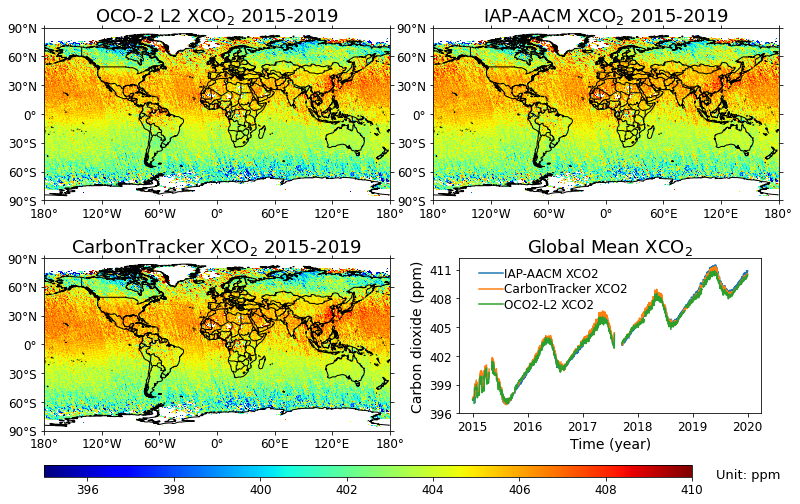

In [20]:
for ii in range(1):
    data_oco2 = [ZZ_mean_all_year_oco2][ii]
    data_naq = [ZZ_mean_all_year_naq][ii]
    data_ct = [ZZ_mean_all_year_ct][ii]
    name = [''][ii]
    #print(lon_g[1],lat_g[1])
    proj = ccrs.PlateCarree(central_longitude=0)
    #创建图形
    fig = plt.figure(figsize=(12, 8))
    fig_ax1 = fig.add_axes([0.0, 0.75, 0.4, 0.4],projection = proj)
    #fig_ax2 = fig.add_axes([0.55, 0.25, 0.5, 0.5],projection = proj)
    #设置边界
    leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
    img_extent = [leftlon, rightlon, lowerlat, upperlat]
    fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
    #绘制海岸线和湖泊等地理特征
    fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
    fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
    #设置刻度及刻度标签格式
    plt.tick_params(top='on', right='on', which='both')#显示轴刻度
    fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
    fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()
    lat_formatter = cticker.LatitudeFormatter()
    fig_ax1.xaxis.set_major_formatter(lon_formatter)
    fig_ax1.yaxis.set_major_formatter(lat_formatter)
    fig_ax1.tick_params(axis='both', labelsize=12)
    #由于0°空白，增加绘图序列，补全0°空白
    from cartopy.util import add_cyclic_point
    pcm = fig_ax1.pcolormesh(X,Y,data_oco2, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=395, vmax=410,)
    #fig_ax1.tick_params(axis='both', labelsize=12)
    #position=fig.add_axes([0.42, 0.80, 0.013, 0.3])
    #cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
    #cb = fig.colorbar(pcm,cax=position,format='%.0f',)
    #cb.ax.tick_params(labelsize=12) 
    fig_ax1.set_title(f'OCO-2 L2 XCO$_2$ 2015-2019',loc='center',fontsize =18)
    #fig_ax1.text(170,100,'Unit: ppm',fontsize=13)

    
    fig_ax2 = fig.add_axes([0.45, 0.75, 0.4, 0.4],projection = proj)
    leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
    img_extent = [leftlon, rightlon, lowerlat, upperlat]
    fig_ax2.set_extent(img_extent, crs=ccrs.PlateCarree())
    #绘制海岸线和湖泊等地理特征
    fig_ax2.add_feature(cfeature.COASTLINE.with_scale('50m'))
    fig_ax2.add_feature(cfeature.BORDERS.with_scale('50m'))
    #设置刻度及刻度标签格式
    plt.tick_params(top='on', right='on', which='both')#显示轴刻度
    fig_ax2.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
    fig_ax2.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()
    lat_formatter = cticker.LatitudeFormatter()
    fig_ax2.xaxis.set_major_formatter(lon_formatter)
    fig_ax2.yaxis.set_major_formatter(lat_formatter)
    #由于0°空白，增加绘图序列，补全0°空白
    from cartopy.util import add_cyclic_point
    pcm = fig_ax2.pcolormesh(X,Y,data_naq, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=395, vmax=410,)
    fig_ax2.tick_params(axis='both', labelsize=12)
    #position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
    #cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
    fig_ax2.set_title(f'IAP-AACM XCO$_2$ 2015-2019',loc='center',fontsize =18)
    position=fig.add_axes([0.00, 0.32, 0.75, 0.02])
    cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
    cb.ax.tick_params(labelsize=12) 
    fig_ax1.set_title(f'OCO-2 L2 XCO$_2$ 2015-2019',loc='center',fontsize =18)
    fig_ax1.text(520,-380,'Unit: ppm',fontsize=13)
    
    fig_ax3 = fig.add_axes([0.00, 0.35, 0.4, 0.4],projection = proj)
    leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
    img_extent = [leftlon, rightlon, lowerlat, upperlat]
    fig_ax3.set_extent(img_extent, crs=ccrs.PlateCarree())
    #绘制海岸线和湖泊等地理特征
    fig_ax3.add_feature(cfeature.COASTLINE.with_scale('50m'))
    fig_ax3.add_feature(cfeature.BORDERS.with_scale('50m'))
    #设置刻度及刻度标签格式
    plt.tick_params(top='on', right='on', which='both')#显示轴刻度
    fig_ax3.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
    fig_ax3.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()
    lat_formatter = cticker.LatitudeFormatter()
    fig_ax3.xaxis.set_major_formatter(lon_formatter)
    fig_ax3.yaxis.set_major_formatter(lat_formatter)
    #由于0°空白，增加绘图序列，补全0°空白
    from cartopy.util import add_cyclic_point
    pcm = fig_ax3.pcolormesh(X,Y,data_ct, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=395, vmax=410,)
    fig_ax3.tick_params(axis='both', labelsize=12)
    #position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
    #cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
    fig_ax3.set_title(f'CarbonTracker XCO$_2$ 2015-2019',loc='center',fontsize =18)


    fig_ax4= fig.add_axes([0.48, 0.43, 0.35, 0.27])
    fig_ax4.plot(x_5yr ,np.array(naq_5yr),label='IAP-AACM XCO2')
    fig_ax4.plot(x_5yr ,ct_5yr,label='CarbonTracker XCO2')
    fig_ax4.plot(x_5yr ,oco2_5yr,label='OCO2-L2 XCO2')
    

    leg=fig_ax4.legend(prop={'size':12},frameon=False,loc="upper left",\
            ncol=1,bbox_to_anchor=(0.05,0.97),borderaxespad = 0.,markerscale=5.,handletextpad=0.1,labelspacing=0.2,columnspacing=0.1) #图例
    fig_ax4.set_title(f'Global Mean XCO$_2$',loc='center',fontsize =18)
    xticks_positions = [0, 365, 365*2, 365*3, 365*4, 365*5,]
    xticks_labels = ['2015', '2016', '2017', '2018', '2019', '2020', ]
    yticks_positions = [396, 399, 402, 405, 408, 411,]
    yticks_labels = ['396', '399', '402', '405', '408', '411', ]
    fig_ax4.set_xticks(xticks_positions)
    fig_ax4.set_xticklabels(xticks_labels, fontsize=12)
    fig_ax4.set_yticks(yticks_positions)
    fig_ax4.set_yticklabels(yticks_labels, fontsize=12)
    fig_ax4.tick_params(axis='both', labelsize=12)
    fig_ax4.set_ylabel('Carbon dioxide (ppm)', fontsize=14)  # 添加纵坐标标签
    fig_ax4.set_xlabel('Time (year)', fontsize=14)  # 添加纵坐标标签



    #ax.set_title(f'NAQPMS.02{var} CO2 {mon}',loc='center',fontsize =20,y =1.01)
    plt.rcParams['savefig.dpi'] = 500 
    plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图/oco2_ct_iapaacm_xco2_5yr.r6.png',bbox_inches='tight')